## 3.0 Introduction

So far we've worked with toy vectors — small, hand-crafted examples designed to illustrate mathematical ideas. In this lecture we see real data for the first time. The central theme is one you already know: **a dataset is a matrix**, and every operation we perform on it has a linear algebra interpretation.

We'll use three tools that together form the standard modern data science workflow:

1. **pandas** — for loading, inspecting, and cleaning data
2. **NumPy** — for all linear algebra: means, standard deviations, norms, standardization
3. **scikit-learn** — for standardization (this lecture) and modeling (Lecture 4+)

The typical flow looks like this:

$$\text{Raw data} \xrightarrow{\text{pandas}} \text{clean DataFrame} \xrightarrow{\texttt{.to\_numpy()}} \text{NumPy matrix} \xrightarrow{\text{sklearn}} \text{model}$$

By the end of this lecture you'll be able to load a real dataset, explore its structure, compute column statistics using linear algebra, standardize the data, and visualize cluster structure — all while connecting each step back to the mathematics you already know from Lectures 1 and 2. 

In [1]:
# Run this cell first to import all libraries for this lecture
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 3.1 The Dataset as a Matrix

We'll work with the **[Iris dataset](https://en.wikipedia.org/wiki/Iris_flower_data_set)** — one of the most well-known datasets in machine learning. It contains measurements of 150 iris flowers across three species: `Setosa`, `Versicolor`, and `Virginica`. For each flower, four features were measured (all in centimeters):

1. `sepal_length`
2. `sepal_width`
3. `petal_length`
4. `petal_width`

We'll load the dataset directly from the course GitHub repository using `pd.read_csv()` — the standard way to load tabular data in Python. An internet connection is required.

In [ ]:
# Load the Iris dataset from the course GitHub repository
url = 'https://raw.githubusercontent.com/ajorgen1/Linear-Algebra-With-Applications/main/datasets/iris.csv'
df = pd.read_csv(url) # It's common to call the Panda's data frame object "df."

# Preview the first few rows
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa


### The DataFrame and the Matrix

A pandas **DataFrame** is a generalization of a matrix — it can hold mixed types across columns, not just numbers. Our Iris DataFrame has 5 columns and 150 rows (shape $(150, 5)$), but the fifth column (`species`) contains strings, not numbers. A matrix in the linear algebra sense can only hold numbers, so the full DataFrame is not a matrix in the strict mathematical definition of the term.

In practice we split the DataFrame into two objects:

- The **data matrix** $X \in \mathbb{R}^{150 \times 4}$ — the four numeric feature columns. Each row is a data vector $\mathbf{x}_i \in \mathbb{R}^4$ (one flower's measurements), and each column is a **feature vector** in $\mathbb{R}^{150}$ (one measurement across all flowers).
- The **label vector** $\mathbf{y} \in \mathbb{R}^{150}$ — the species column. It's common to encode these as integers ($0 = $ Setosa, $1 = $ Versicolor, $2 = $ Virginica). This tells us the true **class** of each flower.

This features/labels split is the standard convention in machine learning — the data matrix $X$ goes into the model, and the label vector $\mathbf{y}$ is used to train or evaluate it.

**Question.** The DataFrame has shape $(150, 5)$. What are the dimensions $m \times n$ of the data matrix $X$? What about the label vector $\mathbf{y}$ — what space does it live in?

In [ ]:
# .shape returns (rows, columns) -- the dimensions of the matrix, same as numpy's shape attribute. 
print('DataFrame shape:', df.shape)

# .info() gives a concise summary: column names, data types, non-null counts
df.info()

DataFrame shape: (150, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [5]:
# .describe() computes summary statistics for each numerical column
# count, mean, std, min, quartiles, max
df.describe().round(4)

,sepal_length,sepal_width,petal_length,petal_width
count,150.0000,150.0000,150.0000,150.0000
mean,5.8433,3.0573,3.7580,1.1993
std,0.8281,0.4359,1.7653,0.7622
min,4.3000,2.0000,1.0000,0.1000
25%,5.1000,2.8000,1.6000,0.3000
50%,5.8000,3.0000,4.3500,1.3000
75%,6.4000,3.3000,5.1000,1.8000
max,7.9000,4.4000,6.9000,2.5000


The numbers in `.describe()` are called the features' **summary statistics** and result from linear algebra operations on the column vectors of $X$. We'll derive these using linear algebra in Section 3.3.

## 3.2 Extracting the Matrix

Once we're satisfied with the DataFrame, we convert it to a NumPy array using `.to_numpy()`. After that, all of our math — means, norms, standardization — is done with NumPy.

Pandas has two indexing tools, `.iloc[]` (by integer position) and `.loc[]` (by label), that are useful for exploration and inspection, but for mathematical operations we work directly with the NumPy array $X$.

In NumPy:

- `X[i, j]` — single entry at row $i$, column $j$
- `X[i, :]` — entire row $i$ (a data vector $\mathbf{x}_i$)
- `X[:, j]` — entire column $j$ (a feature vector)
- `X[2:5, :]` — rows 2, 3, 4 (a slice)

In Python, indexing starts at $0$, so the first row is `X[0, :]` and the last is `X[149, :]`.

In [6]:
# Extract the raw NumPy matrix from the DataFrame
# .to_numpy() converts a DataFrame (or column selection) to a NumPy array
X = df[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']].to_numpy()
y = pd.Categorical(df['species']).codes  # encode species as integers: 0, 1, 2
feature_names = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
species_names = df['species'].unique()

print('X shape:', X.shape)
print('y shape:', y.shape)
print('Species:', species_names)

X shape: (150, 4)
y shape: (150,)
Species: ['Setosa' 'Versicolor' 'Virginica']


In [7]:
# Extract the first data vector x_1 -- the first flower's measurements
x1 = X[0, :]   # row 0, all columns
print('First data vector x_1:', x1)
print('Shape:', x1.shape)

# This is a vector in R^4 -- one flower's four measurements

First data vector x_1: [5.1 3.5 1.4 0.2]
Shape: (4,)


In [8]:
# Extract the petal length column -- a feature vector in R^150
petal_length = X[:, 2]   # all rows, column 2
print('Petal length feature vector (first 10):', petal_length[:10])
print('Shape:', petal_length.shape)

Petal length feature vector (first 10): [1.4 1.4 1.3 1.5 1.4 1.7 1.4 1.5 1.4 1.5]
Shape: (150,)


In [9]:
# Boolean masking: extract only Setosa flowers (y == 0)
# This creates a submatrix of shape (50, 4)
mask = (y == 0)               # boolean array: True where y is 0
X_setosa = X[mask, :]         # keep only rows where mask is True
print('Setosa submatrix shape:', X_setosa.shape)
print('First 3 Setosa flowers:')
print(X_setosa[:3, :])

Setosa submatrix shape: (50, 4)
First 3 Setosa flowers:
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]]


**Note on boolean masking.** The expression `y == 0` produces an array of `True`/`False` values — one per row. Passing it as a row index keeps only the rows where the condition is `True`. This is how you extract a subset of the data matrix corresponding to a particular class or condition.

**Question.** What shape would `X[y == 1, :]` have? What about `X[y == 2, 2:]`?

## 3.3 Column Statistics as Linear Algebra

The summary statistics in `.describe()` have precise linear algebra interpretations. Let $\mathbf{x} \in \mathbb{R}^n$ be a feature column (one column of $X$, with $n = 150$). Let $\mathbf{1} \in \mathbb{R}^n$ be the ones vector (as seen in from Homework 1).

**The column mean** is:

$$\bar{x} = \frac{1}{n}\sum_{i=1}^n x_i = \frac{1}{n}\mathbf{1}^T\mathbf{x}$$

This is a dot product. Recall that $\mathbf{1}^T\mathbf{x} = \sum_{i=1}^n x_i$, so dividing by $n$ gives the mean.

**The column standard deviation** is the RMS of the mean-centered vector. Define the **mean-centered vector** $\tilde{\mathbf{x}} = \mathbf{x} - \bar{x}\mathbf{1}$. Then:

$$\sigma = \sqrt{\frac{1}{n}\sum_{i=1}^n (x_i - \bar{x})^2} = \sqrt{\frac{\|\tilde{\mathbf{x}}\|^2}{n}} = \text{RMS}(\tilde{\mathbf{x}})$$

The standard deviation is exactly the RMS of the mean-centered vector — the same RMS from Section 2.4, applied to $\tilde{\mathbf{x}}$ instead of $\mathbf{x}$.

In [10]:
# Work with the sepal length column
x = X[:, 0]         # sepal length, shape (150,)
n = x.shape[0]      # number of entries; .shape[0] generalizes to matrices, len() does not

# Mean via dot product with ones vector
ones = np.ones(n)
x_bar = np.dot(ones, x) / n

print(f'Mean via dot product: {x_bar:.4f}')
print(f'Mean via np.mean():   {np.mean(x):.4f}')

Mean via dot product: 5.8433
Mean via np.mean():   5.8433


In [11]:
# Mean-centered vector: subtract the mean from every entry
x_centered = x - x_bar   # vector subtraction (broadcasting)

# Verify: mean of centered vector should be 0
print(f'Mean of centered vector: {np.mean(x_centered):.10f}')  # essentially 0

# Standard deviation = RMS of the mean-centered vector
# RMS(x_centered) = norm(x_centered) / sqrt(n), so std = norm(x_centered) / sqrt(n)
std_rms   = np.linalg.norm(x_centered) / np.sqrt(n)
std_numpy = np.std(x)   # np.std() uses ddof=0 by default -- matches our formula

print(f'Std via RMS:      {std_rms:.4f}')
print(f'Std via np.std(): {std_numpy:.4f}')

Mean of centered vector: 0.0000000000
Std via RMS:      0.8253
Std via np.std(): 0.8253


**Note on `ddof`.** `np.std()` divides by $n$ by default — the *population* standard deviation, which matches our formula. Pandas `.std()` divides by $n-1$ by default (the *sample* standard deviation used in statistics). For $n = 150$ the difference is negligible. We use `np.std()` throughout this course since it matches the RMS formula exactly, with no extra arguments needed.

In [12]:
# Summary: compute mean, std, and norm for all four feature columns using NumPy
#
# f-string formatting: {value:<25} left-aligns value in a field 25 characters wide
#                      {value:>8}  right-aligns value in a field 8 characters wide
# The header and data rows use the same widths so columns line up
print(f"{'Feature':<25} {'Mean':>8} {'Std':>8} {'Norm':>10}")
print('-' * 55)
for j, name in enumerate(feature_names):
    col = X[:, j]
    col_mean = np.mean(col)
    col_std  = np.std(col)
    col_norm = np.linalg.norm(col)
    print(f'{name:<25} {col_mean:>8.4f} {col_std:>8.4f} {col_norm:>10.4f}')

Feature                       Mean      Std       Norm
-------------------------------------------------------
sepal_length                5.8433   0.8253    72.2762
sepal_width                 3.0573   0.4344    37.8206
petal_length                3.7580   1.7594    50.8204
petal_width                 1.1993   0.7597    17.3876


**Question.** Look at the norms of the four feature columns. They are all very different. Why would this be a problem if we tried to use these raw vectors to measure similarity between data points, or to cluster them?

## 3.4 Normalize vs. Standardize

There are two different ways to put vectors on a common scale, and it's important not to confuse them.

**Normalization** (Lecture 2) converts a vector to a unit vector by dividing by its norm:

$$\hat{\mathbf{x}} = \frac{\mathbf{x}}{\|\mathbf{x}\|}$$

The result in $\|\hat{\mathbf{x}}\| = 1$. Normalization is used when direction matters and magnitude doesn't — for example, in cosine similarity from Homework 2.

**Standardization** (this lecture) transforms each feature column so it has mean $0$ and standard deviation $1$. For each entry $x_i$ of a feature column $\mathbf{x}$ with mean $\bar{x}$ and standard deviation $\sigma$:

$$z_i = \frac{x_i - \bar{x}}{\sigma}$$

In vector form, standardization is two operations you already know:

$$\mathbf{z} = \frac{1}{\sigma}(\mathbf{x} - \bar{x}\mathbf{1})$$

1. **Mean centering** — subtract $\bar{x}\mathbf{1}$: shifts the vector so its mean is $0$
2. **Scaling** — divide by $\sigma$: scalar multiplication by $\dfrac{1}{\sigma}.$

The results in $\mathbf{z}$ is called a **standardized** (or **z-scored**) vector. Standardization is used when you want features measured in different units — centimeters, dollars, seconds — to contribute equally to distance calculations.

**Key property.** After standardization:

$$\text{RMS}(\mathbf{z}) = 1 \qquad \Longleftrightarrow \qquad \|\mathbf{z}\| = \sqrt{n}$$

Every standardized feature column has exactly the same norm $\sqrt{n}$, regardless of the original scale. This puts all features on equal footing for distance-based algorithms.

In [13]:
# Standardize the sepal length column manually
x = X[:, 0]
x_bar = np.mean(x)
sigma  = np.std(x)    # np.std() uses ddof=0 by default

# Step 1: mean center
x_centered = x - x_bar

# Step 2: scale by 1/sigma
z = x_centered / sigma

print(f'Original:     mean={np.mean(x):.4f}, std={np.std(x):.4f}, norm={np.linalg.norm(x):.4f}')
print(f'Standardized: mean={np.mean(z):.4f}, std={np.std(z):.4f}, norm={np.linalg.norm(z):.4f}')
print(f'sqrt(150) = {np.sqrt(150):.4f}')

Original:     mean=5.8433, std=0.8253, norm=72.2762
Standardized: mean=-0.0000, std=1.0000, norm=12.2474
sqrt(150) = 12.2474


In [16]:
# Standardize all four columns at once using NumPy. 
# You could do this using a loop but below I'll show you a better way.
X_std = np.zeros_like(X, dtype=float)
for j in range(4):
    col = X[:, j]
    X_std[:, j] = (col - np.mean(col)) / np.std(col)

print(f"{'Feature':<25} {'Norm (raw)':>12} {'Norm (standardized)':>20}")
print('-' * 60)
for j, name in enumerate(feature_names):
    print(f'{name:<25} {np.linalg.norm(X[:,j]):>12.4f} {np.linalg.norm(X_std[:,j]):>20.4f}')

Feature                     Norm (raw)  Norm (standardized)
------------------------------------------------------------
sepal_length                   72.2762              12.2474
sepal_width                    37.8206              12.2474
petal_length                   50.8204              12.2474
petal_width                    17.3876              12.2474


Every standardized feature column now has norm $\sqrt{150} \approx 12.2474$. No single feature will dominate distance calculations simply because of its scale.

**Using scikit-learn.** In practice, use `StandardScaler` from `sklearn` rather than implementing standardization by hand. It produces identical results to our manual computation.

In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_std_sklearn = scaler.fit_transform(X)

# Verify it matches our manual computation
print('Max difference between manual and sklearn:',
      np.max(np.abs(X_std - X_std_sklearn)).round(10))

Max difference between manual and sklearn: 0.0


## 3.5 Visualization

Before modeling, it's standard practice to **look at the data**. Plots reveal structure — clusters, outliers, correlations — that summary statistics can miss.

### Histograms

A **histogram** displays the distribution of a single feature. The range of values is divided into equal-width **bins**, and the height of each bar shows how many data points fall into that bin. Tall bars indicate where values are concentrated; short bars (or gaps) indicate where values are rare.

We'll plot a histogram for each feature, before and after standardization.

In [ ]:
# Histograms: distribution of each feature, before and after standardization
fig, axes = plt.subplots(2, 4, figsize=(14, 6))

for j, name in enumerate(feature_names):
    # Raw
    axes[0, j].hist(X[:, j], bins=20, color='steelblue', edgecolor='white')
    axes[0, j].set_title(name, fontsize=10)
    if j == 0:
        axes[0, j].set_ylabel('Raw', fontsize=11)

    # Standardized
    axes[1, j].hist(X_std[:, j], bins=20, color='tomato', edgecolor='white')
    if j == 0:
        axes[1, j].set_ylabel('Standardized', fontsize=11)

plt.suptitle('Iris Feature Distributions: Raw vs. Standardized', fontsize=13)
plt.tight_layout()
plt.show()

**Question.** The shapes of the histograms are identical before and after standardization. What changed? What did standardization *not* change? This is an important distinction — standardization rescales the data but does not alter its distribution shape.

### Scatter Plots

A **scatter plot** displays two features simultaneously. Each data vector $\mathbf{x}_i \in \mathbb{R}^4$ is projected onto two coordinates — say, petal length and petal width — and drawn as a single dot at that location. Scatter plots are useful for spotting clusters, separations, and correlations between pairs of features.

We'll plot petal length vs. petal width, coloring each dot by species, for both the raw and standardized data.

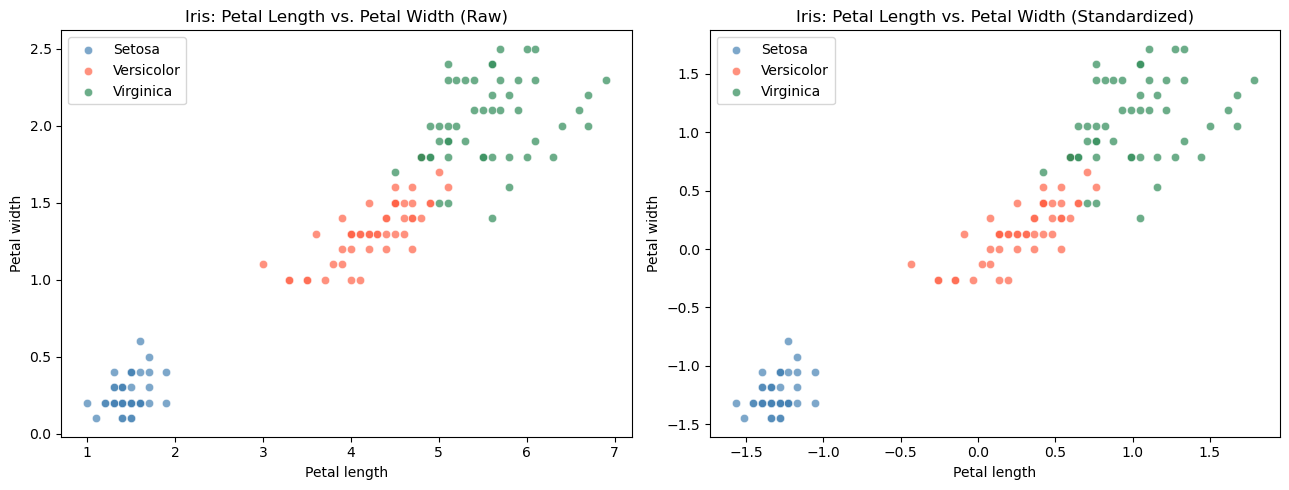

In [18]:
# Scatter plots: petal length vs petal width, raw and standardized side by side
colors = ['steelblue', 'tomato', 'seagreen']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, data, title in zip(axes,
                            [X, X_std],
                            ['Raw', 'Standardized']):
    for k, species in enumerate(species_names):
        mask = (y == k)
        ax.scatter(data[mask, 2], data[mask, 3],
                   color=colors[k], label=species, alpha=0.7,
                   edgecolors='white', linewidth=0.5)
    ax.set_xlabel('Petal length')
    ax.set_ylabel('Petal width')
    ax.set_title(f'Iris: Petal Length vs. Petal Width ({title})')
    ax.legend()

plt.tight_layout()
plt.show()

**Question.** Do the three species form visible clusters in these scatter plots? Standardization changes the axis scales but preserves the cluster structure — the relative positions of the points remain the same. This is exactly the property we need before running k-means in Lecture 4.

## 3.6 Species Centroids

For each species, we can compute the **centroid** — the mean data vector across all flowers of that species. If $\{\mathbf{x}_i\}$ are the data vectors belonging to species $k$, the centroid is:

$$\bar{\mathbf{x}}_k = \frac{1}{n_k}\sum_{i \in \text{species } k} \mathbf{x}_i$$

This is the column-wise mean of the submatrix for species $k$. The centroid $\bar{\mathbf{x}}_k$ is the "center of mass" of the cluster — the point that minimizes the total squared distance to all members of that cluster. We'll return to this idea in Lecture 4.

In [ ]:
# Compute centroid for each species using NumPy
for k, species in enumerate(species_names):
    centroid = np.mean(X[y == k, :], axis=0)   # mean along rows
    print(f'{species} centroid x-bar_{k}: {np.round(centroid, 4)}')

In [ ]:
# Visualize centroids on the scatter plot
fig, ax = plt.subplots(figsize=(7, 5))

for k, species in enumerate(species_names):
    mask = (y == k)
    centroid = np.mean(X[mask, :], axis=0)

    ax.scatter(X[mask, 2], X[mask, 3],
               color=colors[k], alpha=0.4, edgecolors='white', linewidth=0.5)
    ax.scatter(centroid[2], centroid[3],
               color=colors[k], marker='*', s=300,
               edgecolors='black', linewidth=0.8,
               label=f'{species} centroid $\\bar{{\\mathbf{{x}}}}_{k}$')

ax.set_xlabel('Petal length (cm)')
ax.set_ylabel('Petal width (cm)')
ax.set_title('Iris: Petal Length vs. Petal Width with Centroids')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

**Looking ahead: k-means.** Everything in this lecture has been **supervised** by precise knowledge of the class feature **labels**— we used the species labels to color the plots and compute per-species centroids. But what if we didn't have the labels?

The **k-means algorithm** discovers cluster structure with *no labels at all*. It starts with random centroids and repeatedly does two things: assign each data point to its nearest centroid, then recompute each centroid as the mean of its assigned points. After a few iterations it converges to centroids that closely match the species means we computed above — without ever seeing the species column.

We use Iris here precisely because we *do* have ground truth labels — which lets us check afterward whether k-means found something real. In a true unsupervised setting there would be no such check. The labels play no role in the algorithm itself; we only use them to evaluate the result after the fact.

In Lecture 4 we'll implement Lloyd's algorithm by hand, then apply `sklearn`'s `KMeans` to the standardized Iris data and see how well it recovers the three species.